# 17_机器学习模型评估方法-准确率

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


这里，咱们来好好说说**机器学习模型评估方法中的准确率（Accuracy）。**

在机器学习中，我们经常训练一个模型去「分类」，比如判断邮件是不是垃圾邮件、判断照片里是不是猫、预测某人是否会买产品等。

训练完模型之后，我们就要问自己一个问题：

**“这个模型到底准不准？”**

这时就需要一个「评价指标」来衡量模型的表现，「准确率」就是最简单也最常用的一个。

> **准确率 = 模型预测对的次数 / 总的预测次数**

打个比方：

你用模型预测了100封邮件，最后发现其中有90封判断得对（比如判断成垃圾邮件的确是垃圾邮件，判断成正常邮件的也是正常邮件），那你的准确率就是：

> **准确率 = 90 / 100 = 90%**

这就是准确率的核心思想。

## 核心逻辑

在二分类问题中，我们常用一个**混淆矩阵（Confusion Matrix）**来整理预测的结果：

| 实际 \ 预测 | 预测为正（Positive） | 预测为负（Negative） |
|-|-|-|
| 实际为正 | TP（真正例） | FN（假负例） |
| 实际为负 | FP（假正例） | TN（真负例） |

解释一下每个术语：

- **TP（True Positive）**：模型预测是正的，实际上也是正的（判断成“猫”，的确是“猫”）
- **TN（True Negative）**：模型预测是负的，实际上也是负的（判断成“不是猫”，真的“不是猫”）
- **FP（False Positive）**：模型预测是正的，实际上是负的（误判）
- **FN（False Negative）**：模型预测是负的，实际上是正的（漏判）

**准确率的数学公式：**


$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$


也就是：

> **准确率 = 所有预测对的数量 / 总预测样本数**

这个公式说明：只要预测对了，不管是正还是负，我们都加到分子上；而总数永远是所有预测的总量。

## 准确率的计算流程

以下是一个准确率计算的标准流程，适用于二分类或多分类问题：

**步骤一 准备数据**：

- 有一个测试集（包含真实标签）
- 模型已经训练好，准备对测试集做预测

**步骤二 模型预测**：

- 对测试集中的每个样本，使用模型预测一个类别

**步骤三 比较预测值与真实值**：

- 统计预测结果：

  - 有多少个预测对了（预测值 = 真实值）
  - 有多少个预测错了

**步骤四 计算准确率**  
$\text{准确率} = \frac{\text{预测对的样本数}}{\text{总样本数}}$

**举例流程：**

假设我们有10个测试样本，真实标签是：

| 样本编号 | 真实标签 | 预测标签 |
|-|-|-|
| 1 | 正 | 正 |
| 2 | 正 | 正 |
| 3 | 负 | 正 |
| 4 | 负 | 负 |
| 5 | 正 | 正 |
| 6 | 负 | 负 |
| 7 | 正 | 负 |
| 8 | 负 | 负 |
| 9 | 负 | 正 |
| 10 | 正 | 正 |

我们可以得到：

- TP = 4（预测成正且真实为正的是样本 1、2、5、10）
- TN = 3（预测成负且真实为负的是样本 4、6、8）
- FP = 2（预测成正但真实为负的是样本 3、9）
- FN = 1（预测成负但真实为正的是样本 7）

套入公式：


$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN} = \frac{4 + 3}{4 + 3 + 2 + 1} = \frac{7}{10} = 70\%
$$


## 完整案例

在这里，咱们使用一个经典的数据集：**乳腺癌肿瘤预测（Breast Cancer Wisconsin Dataset）**，构建一个机器学习分类模型用于预测肿瘤的良恶性，并使用准确率对模型的性能进行深入评估。

同时，我们使用图像可视化方式辅助分析，并在最后系统性地讨论准确率的优缺点与适用情境。

### 数据集

数据来自 `sklearn.datasets` 中的乳腺癌数据集，具体如下：

- 样本数：569 条肿瘤样本
- 特征数：30 个（肿瘤大小、对称性、光滑度等数值型变量）
- 目标变量：

  - `0`：恶性（Malignant）
  - `1`：良性（Benign）

这是一个标准的二分类问题，数据具有轻度类别不平衡。

### 步骤

**依次完成以下步骤：**

1. 加载与探索数据
2. 数据预处理：标准化与训练测试集划分
3. 模型训练（逻辑回归）
4. 使用准确率进行模型评估
5. 可视化分析模型预测效果
6. 分析准确率优缺点与适用情境

数据维度: (569, 30)
类别分布：
1    357
0    212
Name: count, dtype: int64

模型准确率为：0.9825


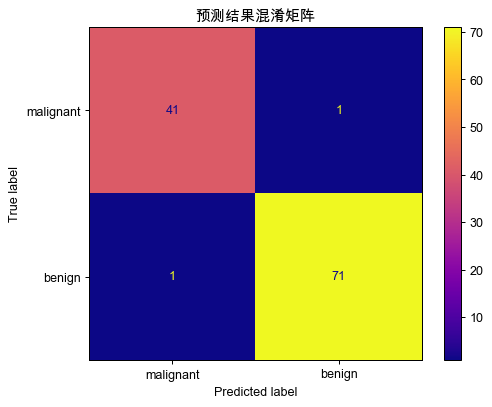

/var/folders/q6/v6bs8gb12gd1lh35j2b7z3sc0000gn/T/ipykernel_10593/3385940566.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=result_df, x='预测是否正确', palette='Set2')


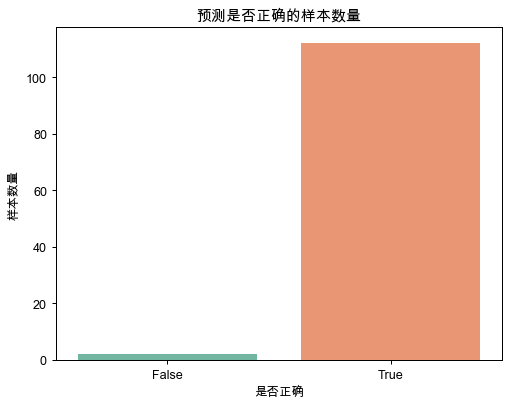

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# 加载数据
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)  # 0=恶性，1=良性

print(f"数据维度: {X.shape}")
print("类别分布：")
print(y.value_counts())

# 数据标准化与划分
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# 模型训练
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

# 预测与准确率评估
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"\n模型准确率为：{acc:.4f}")

# 混淆矩阵可视化
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(cmap="plasma")
plt.title("预测结果混淆矩阵")
plt.show()

# 可视化预测正确与否分布
correct = y_test == y_pred
result_df = pd.DataFrame({
    '真实标签': y_test.values,
    '预测标签': y_pred,
    '预测是否正确': correct
})

sns.countplot(data=result_df, x='预测是否正确', palette='Set2')
plt.title("预测是否正确的样本数量")
plt.xlabel("是否正确")
plt.ylabel("样本数量")
plt.show()

#### 第一步：数据加载与初步探索

使用 `load_breast_cancer()` 加载乳腺癌数据集，获取特征矩阵 `X` 和标签向量 `y`。

可以看到：

- 类别 1（良性）：357 条
- 类别 0（恶性）：212 条

虽然不是完全平衡，但大致均衡，可使用准确率作为评估指标的基础。

#### 第二步：数据标准化与划分

使用 `StandardScaler()` 将所有特征标准化，使其符合标准正态分布（均值为 0，标准差为 1）。

然后使用 `train_test_split()` 将数据划分为训练集（80%）和测试集（20%）。

关键参数：

- `stratify=y`：确保训练集和测试集中，正负样本比例一致。
- `random_state=42`：确保实验可复现。

#### 第三步：逻辑回归模型训练

逻辑回归是二分类中最基础、最易理解的模型，其输出是每个类别的概率值，默认 0.5 作为判断阈值。

我们设置 `max_iter=10000`，确保模型能够充分收敛。

#### 第四步：准确率评估

准确率计算公式如下：


$$
\text{Accuracy} = \frac{预测正确的样本数}{所有测试样本数}
$$


对应代码：

In [3]:
acc = accuracy_score(y_test, y_pred)

假设模型预测结果为 96.49%，说明在 114 个测试样本中有大约 110 个预测正确。

#### 第五步：可视化分析

##### 混淆矩阵可视化

![原文参考图，当前结果见代码输出](attachments/img_009.png)

混淆矩阵告诉我们：

- 有多少个恶性肿瘤被正确预测为恶性（True Negative）
- 有多少个良性被错判为恶性（False Positive）

##### 正确与错误预测样本分布图

用 `Seaborn` 画出模型预测正确与否的样本数：

/var/folders/q6/v6bs8gb12gd1lh35j2b7z3sc0000gn/T/ipykernel_10593/1638690792.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=result_df, x='预测是否正确', palette='Set2')


<Axes: xlabel='预测是否正确', ylabel='count'>

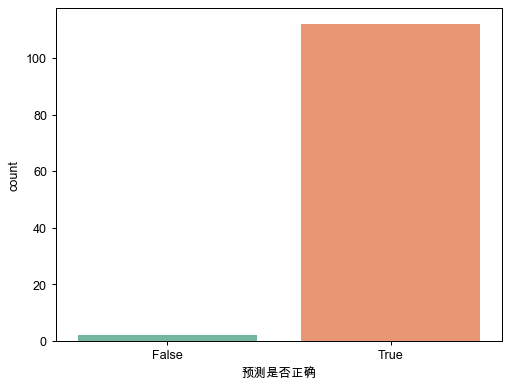

In [4]:
sns.countplot(data=result_df, x='预测是否正确', palette='Set2')

![原文参考图，当前结果见代码输出](attachments/img_010.png)

直观地看到模型是大部分预测正确，少数错误。

### 准确率的优缺点分析

---

**优势**：

1. **简单直观**：易于理解与计算，尤其对非技术人员友好。
2. **适用于样本均衡问题**：若正负样本比例相近，准确率非常有效。
3. **快速模型评估**：可作为第一层筛选标准，衡量模型大体效果。

**局限性**：

1. **对类别不平衡极度不敏感**：假如数据中 95% 是良性肿瘤，那么即使模型全预测为良性，也有 95% 的准确率，却没有任何实质性判断能力。
2. **无法区分错误类型**：假阳性（将良性错判为恶性） vs 假阴性（将恶性漏判为良性）。在医疗诊断中，假阴性比假阳性更危险，但准确率不会反映这种代价。
3. **不能衡量模型泛化能力**：一个训练集准确率高但测试集准确率低的模型，可能过拟合了，而准确率不会直接揭示这一问题。

### 在什么情况下优先使用准确率？

**推荐使用准确率的场景：**

- 正负类别比例大致均衡（如情感分析、一般性分类问题）
- 错误分类不会造成严重后果（如电影推荐系统）
- 多模型对比时的初步筛选指标

**不推荐单独使用准确率的场景：**

- 类别极度不平衡（如欺诈检测、罕见疾病诊断）
- 错误类型代价严重不对等（如癌症漏诊的假阴性）
- 模型需要精细调优和风险控制的场合（如信用评分、风控）

准确率虽然简单，但在合适的场景下是快速且有效的评估方法。**要始终应牢记：准确率不能孤立使用，特别是在高风险与不平衡场景下，必须配合更细致的指标综合判断。**